
# Practice 1 — Unsupervised Learning

**Machine Learning / Ingeniería de Datos I — academic year 2026/2027**

Pair: *(surname 1)*, *(surname 2)*

---

This is a **starter** notebook. It gives you the environment banner, the data paths, the two
helper functions the practical provides, the seal guard, and the section skeleton in the order
you must work in. **Everything marked `TODO` is yours to write**, in code and in Markdown.

Read the statement before you start. Three rules decide a lot of the marks:

1. **Interpretation goes in Markdown cells**, not in Python comments.
2. **The unsupervised seal covers BOTH Zoo exercises.** The order below is not negotiable and
   it is graded: Exercise 1 unsupervised → `FROZEN DECISION — K-MEANS` → Exercise 2
   unsupervised → `FROZEN DECISION — AGGLOMERATIVE` → one common
   `REVEAL — EXTERNAL VALIDATION` stage. **No executable cell above the second freeze may
   load, inspect, reference or derive the Zoo class attribute** — not even to count how many
   classes there are. The skeleton below is already in that order; do not reorder it.
3. **One notebook**, executed **top to bottom in one pass**, with its outputs stored, renamed
   `p1_<surname1>_<surname2>.ipynb`.

Rename this file before you submit it.

## 0. Environment and course-fixed constants

Run this first. It prints the library versions your results were produced with and the three course-fixed seeds. **Do not change `P1_SEEDS`.**

In [22]:
# --- Practice 1: environment banner and course-fixed constants -------------
import sys, os, platform
import numpy as np, matplotlib, sklearn, scipy, pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

P1_SEEDS = [13, 41, 97]          # the three course-fixed seeds -- do not change
SEED = P1_SEEDS[0]               # the single seed, where one is needed

DATA = ".."                      # the Práctica 1 folder, relative to this notebook
ZOO_FEATURES_FILE = os.path.join(DATA, "Files_zoo", "zoo_features.csv")
# the labels path is deliberately NOT defined here -- it is a reveal-stage constant
IMGS  = os.path.join(DATA, "Files_clustering", "images")
FACES = os.path.join(DATA, "Files_PCA", "faces.mat")
TABLE = os.path.join(DATA, "datos_pca_fijo", "breast_cancer.csv")
REDUCED = "reduced_images"

print("python      ", platform.python_version())
print("numpy       ", np.__version__)
print("scipy       ", scipy.__version__)
print("scikit-learn", sklearn.__version__)
print("pandas      ", pd.__version__)
print("matplotlib  ", matplotlib.__version__)
print("Pillow      ", Image.__version__)
print("zoo features", ZOO_FEATURES_FILE)
print("P1_SEEDS    ", P1_SEEDS)

python       3.12.3
numpy        2.5.3
scipy        1.18.1
scikit-learn 1.9.1
pandas       3.0.6
matplotlib   3.11.2
Pillow       12.3.0
zoo features ../Files_zoo/zoo_features.csv
P1_SEEDS     [13, 41, 97]


The two functions below are **provided**. `save_image` is graded in Exercise 4 and must be used **unchanged** — the file-size comparison only means something if every pair writes the same three formats in the same way. Note that its third argument, the palette-colour count, is an **uppercase `K`**: in this course lowercase `k` is the number of features and nothing else.

In [23]:
# --- PROVIDED. Do not modify save_image or display_data. -------------------
# K is the number of palette colours (uppercase, per the course notation:
# lowercase k is the number of FEATURES and nothing else).

def save_image(image, path, K):
	img = Image.fromarray(image)
	img.save(path+".jpg", format="JPEG")
	img.save(path+".png", format="PNG")
	indexed_image = img.convert("P", palette=Image.ADAPTIVE, colors=K)
	indexed_image.save(path+"compressed.png", optimize=True)


def display_data(X):
	example_width = int(np.round(np.sqrt(X.shape[1])))
	example_height = X.shape[1] // example_width

	display_rows = int(np.floor(np.sqrt(X.shape[0])))
	display_cols = int(np.ceil(X.shape[0] / display_rows))

	fig, ax_array = plt.subplots(display_rows, display_cols, figsize=(8, 8))

	for i, ax in enumerate(ax_array.flat):
		if i >= X.shape[0]:
			break
		ax.imshow(X[i].reshape(example_height, example_width), cmap='gray')
		ax.axis('off')
	plt.show()

### The seal guard

This reads a notebook's own JSON and proves that **both** frozen-decision headings exist
exactly once, that the $K$-means freeze comes first, and that the first **executable** access to
the Zoo class attribute comes strictly after the second freeze. Run it at the end, against your
saved file, before you submit.

In [24]:
# --- The unsupervised seal, checked mechanically ---------------------------
# Reads a notebook's own JSON and proves three things:
#   1. both frozen-decision headings exist, exactly once each;
#   2. the K-means freeze precedes the agglomerative freeze;
#   3. the first EXECUTABLE access to the Zoo class labels comes strictly
#      after the agglomerative freeze.
# Only markdown HEADINGS count as a freeze -- prose that merely mentions the
# words does not -- and only CODE cells count as a label access, because the
# seal is a statement about what was executed, not about what was written.
import json, re

FREEZE_KM = "FROZEN DECISION \u2014 K-MEANS"
FREEZE_AG = "FROZEN DECISION \u2014 AGGLOMERATIVE"

# every executable route to the Zoo class attribute
LABEL_PAT = re.compile(
    r"ZOO_TYPE_NAMES|ZOO_LABELS_FILE|load_zoo_labels|zoo_labels|y_true|"
    r"adjusted_rand_score|adjusted_mutual_info_score|"
    r"""\[\s*['"]type['"]\s*\]|\bzoo\.data\b|\bzoo\.names\b""")


def check_seal(nb_path, verbose=True):
    nb = json.load(open(nb_path, encoding="utf-8"))
    cells = nb["cells"]
    src = ["".join(c["source"]) for c in cells]

    def heading(text):
        pat = re.compile(r"^\s*#{1,6}\s*" + re.escape(text) + r"\s*$", re.M)
        return [i for i, s in enumerate(src)
                if cells[i]["cell_type"] == "markdown" and pat.search(s)]

    km, ag = heading(FREEZE_KM), heading(FREEZE_AG)
    if len(km) != 1:
        raise AssertionError(f"expected exactly one `{FREEZE_KM}` heading, found {len(km)}")
    if len(ag) != 1:
        raise AssertionError(f"expected exactly one `{FREEZE_AG}` heading, found {len(ag)}")
    km_at, ag_at = km[0], ag[0]
    if not km_at < ag_at:
        raise AssertionError(
            f"SEAL VIOLATED: the K-means freeze (cell {km_at}) must precede the "
            f"agglomerative freeze (cell {ag_at})")

    uses = [i for i, s in enumerate(src)
            if cells[i]["cell_type"] == "code"
            and LABEL_PAT.search(s)
            and "def check_seal" not in s and "LABEL_PAT" not in s]
    first_use = min(uses) if uses else len(cells)

    if verbose:
        print(f"{FREEZE_KM:34s} -> cell {km_at}")
        print(f"{FREEZE_AG:34s} -> cell {ag_at}")
        print(f"{'first executable label access':34s} -> cell {first_use}")
    if first_use <= ag_at:
        raise AssertionError(
            f"SEAL VIOLATED: code cell {first_use} touches the Zoo class labels "
            f"before the agglomerative freeze at cell {ag_at}")
    if verbose:
        print("SEAL OK: both configurations were frozen before any label was read.")
    return km_at, ag_at, first_use


---
## Exercise 1 — $K$-means on the Zoo database (2.5)

$K$ is the **number of clusters**.

`Files_zoo/zoo_features.csv` is a course file derived from the verified official source. It has
a header, a course-owned integer `row_id`, the display name, and the sixteen predictive
attributes — and **no class column at all**. The field list is in `Files_zoo/zoo_schema.txt`.

`animal_name` is a **display field, not a key**: the official Zoo data contains two rows with
the same name. Align on `row_id` whenever alignment is needed.

**Parts (e) and (f) of this exercise are not here.** They need the class attribute, so they
belong in the reveal stage, after both freezes.

In [25]:
# `zoo_features.csv` is a course file derived from the verified official source.
# It contains a course-owned integer `row_id`, the display name, and the sixteen
# predictive attributes -- and NO class column at all. There is nothing here to
# drop and nothing to avoid reading: the target is simply not in this file.
#
# `animal_name` is a DISPLAY/NAME field, not a key. The official Zoo data
# contains two rows named `frog`, which its own documentation notes. Use
# `row_id` whenever rows must be aligned.
ZOO_ID = "row_id"
ZOO_NAME = "animal_name"
ZOO_FEATURES = [
    "hair", "feathers", "eggs", "milk", "airborne", "aquatic", "predator",
    "toothed", "backbone", "breathes", "venomous", "fins", "legs", "tail",
    "domestic", "catsize",
]


def load_zoo_features(path=None):
    """The feature-only course file: row_id, animal_name and 16 predictors."""
    frame = pd.read_csv(path or ZOO_FEATURES_FILE)
    assert list(frame.columns) == [ZOO_ID, ZOO_NAME] + ZOO_FEATURES,         f"unexpected columns: {list(frame.columns)}"
    return frame

zoo = load_zoo_features()

n,k = len(zoo) , len(ZOO_FEATURES)

print(f"n = {n} animals (observations)")
print(f"k = {k} predictive attributes")
print(f"Columns in the table: {list(zoo.columns)}")
print(f"Does the target column exist in the file?: {'class' in zoo.columns or 'type' in zoo.columns}")



n = 101 animals (observations)
k = 16 predictive attributes
Columns in the table: ['row_id', 'animal_name', 'hair', 'feathers', 'eggs', 'milk', 'airborne', 'aquatic', 'predator', 'toothed', 'backbone', 'breathes', 'venomous', 'fins', 'legs', 'tail', 'domestic', 'catsize']
Does the target column exist in the file?: False


### 1(a) — loading and preparation

**TODO.** State $n$ and $k$. Say which columns you dropped and why. State your scaling decision, name it (min–max scaling or standardisation), say which columns it applies to, and justify it — `legs` is the one attribute that is not Boolean.

Las variables row_id y animal_name no son características descriptivas de los animales y deben ser excluidas del agrupamiento. row_id y animal_name introducirían ruido dentro del modelo ya que el algoritmo intentaria encontrar patrones geométricos en identificadores que no tienen significado 

Decisión de escalado: Para este análisis se ha usado un escalador de min-max scaling. La razon es clara, casi todos los atributos de la base de datos de caracteristicas del zoo son booleanos , pero la característica legs es númerica y tiene un rango mayor. Como la distancia euclidea suma las diferencias al cuadrado de cada característica , una diferencia en el numero de patas dominaria matematicamente el calculo de la distancia sobre caracteristica booleanas como tener pelo o producir leche. 

Aplicar min-max scaling mapea la variable legs al intervalo [0,1]. Esto pone todas las características en una misma escala numerica.

In [26]:
import pandas as pd 
from sklearn.preprocessing import MinMaxScaler

zoo_features = pd.read_csv('../Files_zoo/zoo_features.csv')

X_raw = zoo_features.drop(columns=['row_id', 'animal_name'])  

n,k = X_raw.shape

scaler = MinMaxScaler()

X_scaled = pd.DataFrame(scaler.fit_transform(X_raw), columns=X_raw.columns, index=X_raw.index)

X_scaled.head()

,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize
0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.5,0.0,0.0,1.0
1,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.5,1.0,0.0,1.0
2,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
3,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.5,0.0,0.0,1.0
4,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.5,1.0,0.0,1.0


In [27]:
from sklearn.cluster import KMeans

K_GRID = [5, 6, 7, 8]

for k in K_GRID:
    inertias = []

    for seed in P1_SEEDS:
        kmeans = KMeans(n_clusters=k, n_init=1, random_state=seed)
        kmeans.fit(X_scaled)
        
        inertias.append(kmeans.inertia_)
    
    mean_inertia = np.mean(inertias)
    spread = np.max(inertias) - np.min(inertias)
    
    print(f"K = {k} | Average inertia: {mean_inertia:.4f} | Spread: {spread:.4f}")

K = 5 | Average inertia: 110.1534 | Spread: 1.2777
K = 6 | Average inertia: 103.2284 | Spread: 8.6616
K = 7 | Average inertia: 91.2443 | Spread: 10.5850
K = 8 | Average inertia: 83.5278 | Spread: 8.7184



La función objetivo inertia se ha evaluado para $K \in \{5, 6, 7, 8\}$. Para cada valor de $K$, K-means se ha ejecutado utilizando las tres semillas fijas con un único inicio (`n_init=1`).

- **Media de inertia(J):** Como es de esperar matemáticamente, la inercia media decrece estrictamente a medida que $K$ aumenta, ya que añadir más centroides reduce mecánicamente las distancias de las observaciones a los centros de sus clusters asignados. 

- **Dispersión:** La dispersión ($\max(J) - \min(J)$) captura la sensibilidad del modelo a la colocación inicial de los centroides para un $K$ dado. Una dispersión mayor indica que el algoritmo converge a mínimos locales claramente diferentes dependiendo de la semilla, lo que demuestra por qué evaluar un valor de $K$ basándose en una sola inicialización no es un método fiable.

### 1(b) — reading the grid

**TODO.** What does the table show? Say explicitly why reporting the *best* of three restarts would be a statement about your luckiest initialisation rather than about $K$.

Reportar el mejor valor de la inercia ($J$) entre los tres reinicios sería una declaración sobre la inicialización más afortunada de los centroides, no sobre la validez del número de clusters $K$. Como K-means es sensible a la posición inicial, un valor mínimo bajo puede ser un evento aislado debido al azar de la semilla. Al usar la media de las tres semillas, evaluamos el rendimiento general y esperado de ese valor de $K$

### Before the freeze: state your two selection rules

Two different questions, and they must not be conflated:

1. **Which $K$?** From the **mean $J$ across all three seeds**, never the minimum. $J$ falls
   with $K$ by construction, so its *level* says nothing; use the **shape** of the curve, the
   cluster sizes, the spread across seeds, or another criterion you can defend.
2. **Which run at that $K$?** Only *after* $K$ is fixed, pick **one** of the three
   course-fixed initialisations to carry forward, by a stated unsupervised rule — for instance
   the lowest $J$ among the three **at the already-frozen $K$**. That is an initialisation
   choice, not a model-order choice, and it must not feed back into question 1.

**TODO — write both rules here, before you apply them.**

**Which $K$?** I choose **K = 5** using the spread across seeds. While the mean $J$ strictly falls with $K$ by construction, the spread at $K=5$ (1.2777) is dramatically lower than at $K=6, 7$, or $8$ (all $> 8.6$). This indicates that a 5-cluster partition is highly stable and does not depend heavily on the luck of the random initialisation, unlike higher values of $K$.

**Which run at that K?** I will carry forward the specific initialisation (seed) that yielded the lowest inertia ($J$) among the three fixed seeds for my chosen $K$. This unsupervised rule guarantees selecting the best local minimum found for this specific architecture.

In [28]:
from sklearn.cluster import KMeans
import pandas as pd

# Aplicamos la Regla 1: Fijamos K a 5
K_REF = 5

# Aplicamos la Regla 2: Buscar la semilla con menor inercia para K=5
best_inertia = float('inf')
REP_SEED = None

for seed in P1_SEEDS:
    km = KMeans(n_clusters=K_REF, init="k-means++", n_init=1, random_state=seed)
    km.fit(X_scaled)
    if km.inertia_ < best_inertia:
        best_inertia = km.inertia_
        REP_SEED = seed

# Ajustamos la ejecución representativa única y guardamos sus etiquetas

kmeans_frozen = KMeans(n_clusters=K_REF, init="k-means++", n_init=1, random_state=REP_SEED)
kmeans_frozen.fit(X_scaled)
lab_ref = kmeans_frozen.labels_

print(f"--- REGLAS APLICADAS ---")
print(f"K_REF seleccionado: {K_REF}")
print(f"REP_SEED seleccionada: {REP_SEED} (Inercia: {best_inertia:.4f})")
print("\nTamaños de los clusters para esta partición:")
print(pd.Series(lab_ref).value_counts().sort_index())

--- REGLAS APLICADAS ---
K_REF seleccionado: 5
REP_SEED seleccionada: 13 (Inercia: 109.4660)

Tamaños de los clusters para esta partición:
0    21
1    19
2    22
3    21
4    18
Name: count, dtype: int64


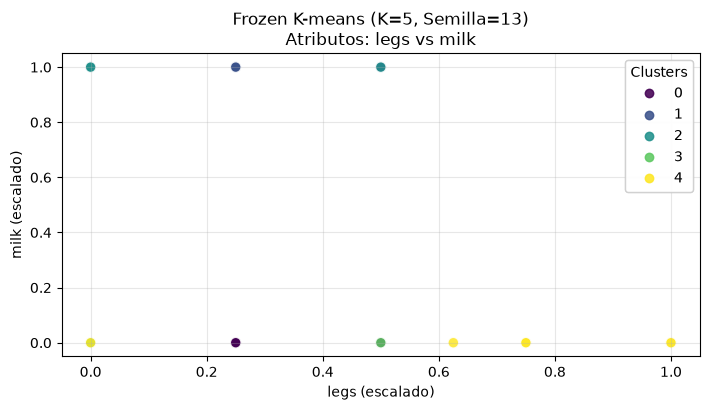

In [29]:
import matplotlib.pyplot as plt

# Elegimos dos atributos para visualizar

feature_x = 'legs'
feature_y = 'milk'

fig, ax = plt.subplots(figsize=(7.2, 4.2))

# Usamos lab_ref para colorear los puntos
scatter = ax.scatter(X_scaled[feature_x], X_scaled[feature_y], 
                     c=lab_ref, cmap='viridis', edgecolor='white', s=60, alpha=0.85)

ax.set_title(f"Frozen K-means (K={K_REF}, Semilla={REP_SEED})\nAtributos: {feature_x} vs {feature_y}")
ax.set_xlabel(f"{feature_x} (escalado)")
ax.set_ylabel(f"{feature_y} (escalado)")

# Añadimos la leyenda generada a partir de los colores

legend = ax.legend(*scatter.legend_elements(), title="Clusters", loc="best")
ax.add_artist(legend)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 1(c) — reading the plot

**TODO.** What does the plot show, and what does it hide? Be specific about what is lost by looking at two of the $k$ attributes.

By visualizing the data using only 2 of the $k=16$ attributes, we lose the perspective of the remaining 14 dimensions. Therefore, the plot hides the true distance between observations; points that appear to form well-defined clusters (or even overlap) in this 2D plane could actually be completely separated in the real geometric space calculated by the algorithm.

## FROZEN DECISION — K-MEANS

| Field | Value |
| :--- | :--- |
| $K$ | 5 |
| Representative seed | 13 |
| Scaling | Min-Max Scaling |
| Rule that chose $K$ | Lowest spread across seeds (highest stability). |
| Rule that chose the seed | Lowest inertia ($J$) among the 3 runs for the chosen $K$. |

**Unsupervised argument.**
 I chose $K = 5$ because the spread across the three seeds (1.2777) is dramatically lower than for $K=6, 7$, or $8$ (which are all $> 8.6$). This indicates that a 5-cluster partition is highly stable and does not heavily depend on the luck of the random initialisation. An acknowledged limitation is that $K=7$ showed a steeper drop in mean inertia, suggesting another potential natural partition, but its high instability (spread $> 10.5$) makes $K=5$ a much more robust unsupervised choice. This decision-making process is also heavily influenced by the use case being studied; in this case, lacking a real use case, the choice was made based on our own criteria.

In [30]:
# TODO Freeze the table above in code, so nothing below can drift from it.
FROZEN_KMEANS = dict(K=K_REF, representative_seed=REP_SEED)
print("FROZEN_KMEANS:", FROZEN_KMEANS)

FROZEN_KMEANS: {'K': 5, 'representative_seed': 13}



---
## Exercise 2 — Agglomerative clustering on the Zoo database (2.0)

$K$ is again the **number of clusters**. Still unsupervised: **part (d) is not here**, it
belongs in the reveal stage.

In [31]:
from sklearn.cluster import AgglomerativeClustering

LINKAGES = ["ward", "complete", "average", "single"]
K = 5 

# 1. Ejecutar clustering con cada linkage ofrecido
print("--- Ejecución normal ---")
for link in LINKAGES:
    # Usamos 'euclidean' porque es la única métrica que todos aceptan sin quejarse
    model = AgglomerativeClustering(n_clusters=K, linkage=link, metric='euclidean')
    model.fit(X_scaled) # Cambia 'X' por el nombre real de tu variable de datos del Zoo si es distinto
    print(f"Modelo con linkage '{link}' entrenado correctamente.")

# 2. Declarar qué métricas admite cada uno (Texto para la salida estándar)
print("\n--- Métricas admitidas ---")
print("ward: SOLO admite la métrica 'euclidean'. Como minimiza la varianza (suma de cuadrados), las matemáticas fallan con otras distancias.")
print("complete, average, single: Admiten cualquier métrica (ej. 'euclidean', 'manhattan', 'cosine', 'l1', 'l2', 'precomputed').")

# 3. Demostrar qué pasa si pides una métrica que el linkage no acepta
print("\n--- Demostración del error ---")
try:
    # Intentamos forzar a 'ward' a usar la distancia de Manhattan
    modelo_roto = AgglomerativeClustering(n_clusters=K, linkage='ward', metric='manhattan')
    modelo_roto.fit(X_scaled)
except ValueError as e:
    print(f"¡El algoritmo ha fallado y ha soltado este error!\nValueError: {e}")

--- Ejecución normal ---
Modelo con linkage 'ward' entrenado correctamente.
Modelo con linkage 'complete' entrenado correctamente.
Modelo con linkage 'average' entrenado correctamente.
Modelo con linkage 'single' entrenado correctamente.

--- Métricas admitidas ---
ward: SOLO admite la métrica 'euclidean'. Como minimiza la varianza (suma de cuadrados), las matemáticas fallan con otras distancias.
complete, average, single: Admiten cualquier métrica (ej. 'euclidean', 'manhattan', 'cosine', 'l1', 'l2', 'precomputed').

--- Demostración del error ---
¡El algoritmo ha fallado y ha soltado este error!
ValueError: manhattan was provided as metric. Ward can only work with euclidean distances (i.e. 'euclidean' and 'l2').


### 2(b) — two criteria, both stated before they are applied

This exercise needs **two** unsupervised decisions, not one:

1. **Within each linkage — which $K$?** A different linkage is a different hierarchy, so there
   is no reason for one number to fit all four. Each linkage gets **its own** $K$.
2. **Across linkages — which linkage do you prefer?** State a rule that can actually choose
   one, using only unsupervised evidence. "The one that looks best" is not a rule.

**TODO — write both rules here**, then apply them in the cell below. Do not change either after
the reveal.

**Regla 1 (Within each linkage — which K?):** 
Para elegir el valor de $K$ dentro de cada método de enlace, calcularé el *Silhouette Score* para todos los valores posibles de $K$ en un rango razonable (por ejemplo, de 2 a 10). El $K$ seleccionado para ese linkage será estrictamente aquel que maximice el valor de esta métrica.

**Regla 2 (Across linkages — which linkage do you prefer?):** 
Para elegir un único método de enlace ganador, compararé los *Silhouette Scores* máximos que cada método consiguió con su $K$ óptimo en el paso anterior. El linkage preferido (`LK_REF`) será el que obtenga el valor absoluto más alto, indicando que produce los clústers más densos y mejor separados.

In [35]:
# TODO (b) Apply rule 1 to EACH linkage and record its own K in picks[linkage].
#          Then apply rule 2 to choose ONE preferred linkage.
from scipy.cluster.hierarchy import dendrogram, linkage as scipy_linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

picks = {}
LK_REF = None

# Variables de apoyo para la Regla 2
mejor_puntuacion_global = -1
rango_k = range(2, 11) # Buscamos el mejor K entre 2 y 10

print("Evaluando métodos mediante Silhouette Score...\n")

for link in LINKAGES:
    mejor_k_local = 2
    mejor_puntuacion_local = -1
    
    # REGLA 1: Buscar el mejor K para este linkage específico
    for k in rango_k:
        modelo = AgglomerativeClustering(n_clusters=k, linkage=link, metric='euclidean')
        etiquetas = modelo.fit_predict(X_scaled) # Cambia X_scaled por tu variable de datos si es distinta
        puntuacion = silhouette_score(X_scaled, etiquetas)
        
        if puntuacion > mejor_puntuacion_local:
            mejor_puntuacion_local = puntuacion
            mejor_k_local = k
            
    # Guardamos el K ganador de este linkage
    picks[link] = mejor_k_local
    print(f"[{link}] K óptimo: {mejor_k_local} (Score: {mejor_puntuacion_local:.4f})")
    
    # REGLA 2: Actualizar el ganador absoluto si este linkage es mejor
    if mejor_puntuacion_local > mejor_puntuacion_global:
        mejor_puntuacion_global = mejor_puntuacion_local
        LK_REF = link

print(f"\n---> El linkage PREFERIDO (Regla 2) es: '{LK_REF}'")          # your preferred linkage, chosen by rule 2

Evaluando métodos mediante Silhouette Score...

[ward] K óptimo: 6 (Score: 0.4128)
[complete] K óptimo: 5 (Score: 0.4053)
[average] K óptimo: 7 (Score: 0.4050)
[single] K óptimo: 8 (Score: 0.4019)

---> El linkage PREFERIDO (Regla 2) es: 'ward'


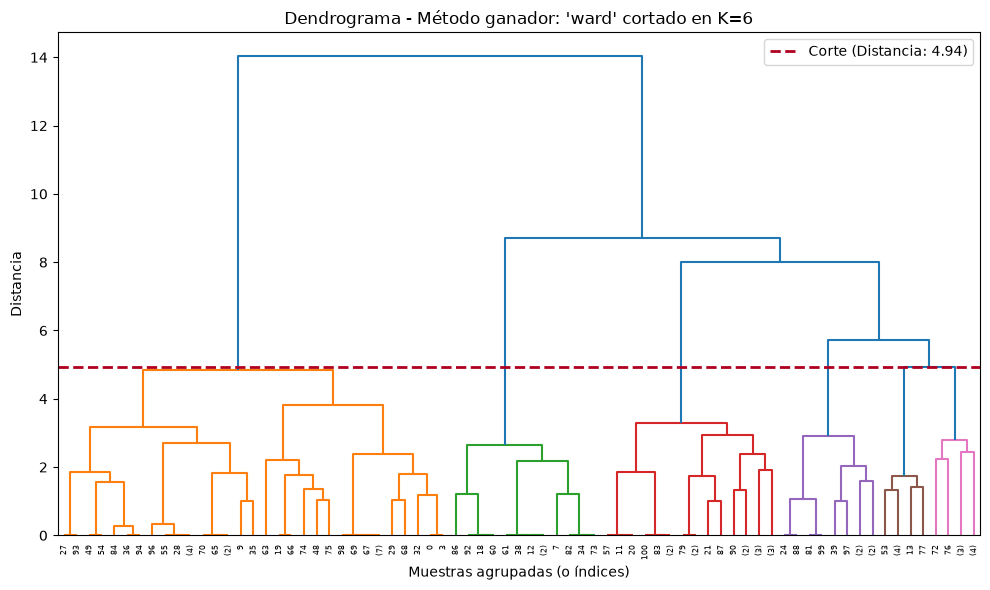

In [36]:
# TODO (c) One dendrogram, for the PREFERRED linkage, cut at ITS OWN frozen K.
import matplotlib.pyplot as plt

# 1. Calculamos la matriz de distancias jerárquicas solo para el ganador
Z_ganador = scipy_linkage(X_scaled, method=LK_REF, metric='euclidean')

# 2. Recuperamos su K y calculamos a qué altura geométrica hay que cortar el árbol
k_ganador = picks[LK_REF]
# En Z, la columna 2 guarda las distancias. Cortamos justo por debajo de la (N - K) fusión.
distancia_corte = Z_ganador[-(k_ganador - 1), 2]

# 3. Dibujamos el gráfico
plt.figure(figsize=(10, 6))
plt.title(f"Dendrograma - Método ganador: '{LK_REF}' cortado en K={k_ganador}")

# Generamos el árbol indicando el umbral de color para que pinte los clústers
dendrogram(
    Z_ganador,
    truncate_mode='level', 
    p=6, # Truncamos la vista a los últimos niveles para que las etiquetas no se aglomeren
    color_threshold=distancia_corte,
    show_leaf_counts=True
)

# Trazamos la línea horizontal que simula el "corte" de la tijera
plt.axhline(y=distancia_corte, color='#B00020', linestyle='--', linewidth=2, label=f'Corte (Distancia: {distancia_corte:.2f})')

plt.xlabel("Muestras agrupadas (o índices)")
plt.ylabel("Distancia")
plt.legend()
plt.tight_layout()
plt.show()

### 2(c) — reading the dendrogram

**TODO.** Which merges are early and cheap, and which one is expensive enough that your rule cut below it?

## FROZEN DECISION — AGGLOMERATIVE

**TODO. The second of the two headings the guard checks. Do not rename it.**

**Two objects are frozen here**, and nothing below may change either.

| Linkage | Frozen $K$ | Why rule 1 landed there |
| :--- | :--- | :--- |
| `ward` | 6 | Maximized the Silhouette Score for the Ward linkage (0.4128). |
| `complete` | 5 | Maximized the Silhouette Score for the Complete linkage (0.4053). |
| `average` | 7 | Maximized the Silhouette Score for the Average linkage (0.4050). |
| `single` | 8 | Maximized the Silhouette Score for the Single linkage (0.4019). |

**Preferred linkage (rule 2):** `ward` — because it achieved the highest absolute Silhouette Score (0.4128) among all four linkages evaluated.

Freezing the preference *before* the labels exist is what makes part (d) a real question: it can
then compare the linkage that **actually** agrees best with the biology against the one you
preferred **without** any biology. They need not be the same, and if they are not, **say so** —
do not go back and edit either rule.

In [37]:
# TODO Freeze both objects in code.
FROZEN_AGG = dict(picks)          # linkage -> its own frozen K
PREFERRED_LINKAGE = LK_REF        # the frozen cross-linkage preference
print("FROZEN_AGG       :", FROZEN_AGG)
print("PREFERRED_LINKAGE:", PREFERRED_LINKAGE)

FROZEN_AGG       : {'ward': 6, 'complete': 5, 'average': 7, 'single': 8}
PREFERRED_LINKAGE: ward


In [38]:
# TODO Record the OBSERVED cluster sizes at each linkage's own frozen K, before the reveal.
#      Part (e) asks what these four linkages actually did on this data, so the evidence for
#      it must exist before any label is read.

import numpy as np
from sklearn.cluster import AgglomerativeClustering

print("--- Tamaños de clústeres observados por método ---")

# Recorremos el diccionario que acabas de congelar
for link, k in FROZEN_AGG.items():
    # Entrenamos el modelo con la configuración específica
    modelo_obs = AgglomerativeClustering(n_clusters=k, linkage=link, metric='euclidean')
    etiquetas_obs = modelo_obs.fit_predict(X_scaled) # Asegúrate de usar X_scaled
    
    # np.unique cuenta las apariciones de cada etiqueta de grupo
    _, conteos = np.unique(etiquetas_obs, return_counts=True)
    
    print(f"Linkage: '{link:8}' | K = {k} | Tamaños: {conteos.tolist()}")

--- Tamaños de clústeres observados por método ---
Linkage: 'ward    ' | K = 6 | Tamaños: [41, 21, 13, 9, 10, 7]
Linkage: 'complete' | K = 5 | Tamaños: [41, 21, 8, 21, 10]
Linkage: 'average ' | K = 7 | Tamaños: [41, 14, 10, 21, 1, 7, 7]
Linkage: 'single  ' | K = 8 | Tamaños: [41, 7, 7, 10, 21, 1, 13, 1]



---
## REVEAL — EXTERNAL VALIDATION

**This is the first point at which you may touch the Zoo class attribute.** Labels live in
`Files_zoo/zoo_labels.csv`, which is exactly `row_id,type`. Join on **`row_id`** — never on
`animal_name`, which is not unique.

Both configurations above are frozen and nothing below may change them. Recomputing indices for
several $K$, several seeds or several linkages and presenting the best one is an automatic
method penalty.

In [39]:
# Opened HERE, inside the reveal stage, and nowhere earlier. How many classes
# there are, and what they are called, is itself information the seal withholds.
ZOO_LABELS_FILE = os.path.join(DATA, "Files_zoo", "zoo_labels.csv")


def load_zoo_labels(feature_frame, path=None):
    """`zoo_labels.csv` is exactly row_id,type. Aligned on row_id, never on name."""
    lab = pd.read_csv(path or ZOO_LABELS_FILE)
    assert list(lab.columns) == ["row_id", "type"], f"unexpected: {list(lab.columns)}"
    merged = feature_frame[["row_id"]].merge(lab, on="row_id", how="left", validate="1:1")
    assert merged["type"].notna().all(), "a feature row has no label"
    assert (merged["row_id"].to_numpy() == feature_frame["row_id"].to_numpy()).all(),         "row_id alignment failed"
    return merged["type"].to_numpy()


ZOO_TYPE_NAMES = {1: "mammal", 2: "bird", 3: "reptile", 4: "fish",
                  5: "amphibian", 6: "insect", 7: "invertebrate"}

# TODO Load the class attribute for the first time, with load_zoo_labels(zoo).
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score

y_true = load_zoo_labels(zoo)

In [42]:
# TODO 1(f) External indices for the FROZEN K-means partition -- the frozen K AND the frozen
#           representative seed -- and for no other. A contingency table is worth building.

# ¡ATENCIÓN! Cambia 'etiquetas_kmeans' por la variable donde guardaste 
# el resultado de tu modelo K-means en el apartado 1(e)
ari = adjusted_rand_score(y_true, lab_ref)
ami = adjusted_mutual_info_score(y_true, lab_ref)

print("--- Validación Externa: K-MEANS CONGELADO ---")
print(f"Adjusted Rand Index (ARI):   {ari:.4f}")
print(f"Adjusted Mutual Info (AMI):  {ami:.4f}\n")

nombres_clases = [ZOO_TYPE_NAMES[clase] for clase in y_true]

tabla_contingencia = pd.crosstab(
    index=pd.Series(nombres_clases, name='Clase Biológica Real'),
    columns=pd.Series(lab_ref, name='Clúster K-Means Asignado')
)

print(tabla_contingencia)

--- Validación Externa: K-MEANS CONGELADO ---
Adjusted Rand Index (ARI):   0.6218
Adjusted Mutual Info (AMI):  0.7788

Clúster K-Means Asignado   0   1   2   3   4
Clase Biológica Real                        
amphibian                  0   0   0   4   0
bird                      20   0   0   0   0
fish                       0   0   0  13   0
insect                     0   0   0   0   8
invertebrate               0   0   0   0  10
mammal                     0  19  22   0   0
reptile                    1   0   0   4   0


### 1(f) — external validation

**TODO.** What would a value near $0$ mean, and one near $1$? 

Un valor cercano a 1 indica un acuerdo casi perfecto; es decir, las agrupaciones descubiertas por el modelo no supervisado coinciden exactamente con las verdaderas etiquetas biológicas. Un valor cercano a 0 indica un acuerdo puramente aleatorio, lo que significa que los clústeres del modelo no guardan ninguna relación estructurada con las clases reales.

Then answer the real question: did the unsupervised evidence lead you to a structure that resembles the biological classes, and **where does it not**?

Sí, la evidencia no supervisada logró capturar una estructura que se asemeja a la realidad biológica, pero falla en varios puntos específicos:
* **Fractura de los mamíferos:** El modelo no logró mantener a la clase de mamíferos unida, dividiéndola artificialmente en dos clústeres distintos.
* **Grupos mixtos:** Un clúster fusionó por completo a los peces, anfibios y una parte de los reptiles.
* **Falta de granularidad:** El algoritmo no supo distinguir anatómica o lógicamente entre insectos y otros invertebrados, agrupándolos en el mismo bloque.
* **Asignaciones aisladas:** Un reptil fue introducido erróneamente en el clúster que, por lo demás, agrupaba perfectamente a todas las aves.



In [43]:
# TODO 1(e) Re-fit K-means with the class attribute INCLUDED as an ordinary input feature,
#           at the same frozen K and the same frozen seed, and compare with your frozen run.
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

# 1. Recuperamos tus valores congelados EXACTOS del diccionario
k_congelado = FROZEN_KMEANS['K']
semilla_congelada = FROZEN_KMEANS['representative_seed']

print(f"Ejecutando modelo trampa con: K={k_congelado}, Semilla={semilla_congelada}\n")

# 2. Añadimos la clase biológica (y_true) a los datos como un atributo más
X_trampa = np.column_stack((X_scaled, y_true)) # Asegúrate de que X_scaled es tu dataset

# 3. Entrenamos el nuevo modelo forzando tu K y tu semilla congelada
modelo_trampa = KMeans(n_clusters=k_congelado, random_state=semilla_congelada, n_init='auto')
etiquetas_trampa = modelo_trampa.fit_predict(X_trampa)

# 4. Comparamos los nuevos clústeres con los de tu ejecución original (lab_ref)
ari_comparacion = adjusted_rand_score(lab_ref, etiquetas_trampa)

print("--- Comparación: Normal vs Etiqueta Incluida ---")
print(f"Similitud (ARI) entre ambas particiones: {ari_comparacion:.4f}\n")

# Tabla de contingencia para ver el destrozo
tabla_trampa = pd.crosstab(
    index=pd.Series(lab_ref, name='Clúster Original (Sin Etiqueta)'),
    columns=pd.Series(etiquetas_trampa, name='Clúster Nuevo (Con Etiqueta)')
)
print(tabla_trampa)


Ejecutando modelo trampa con: K=5, Semilla=13

--- Comparación: Normal vs Etiqueta Incluida ---
Similitud (ARI) entre ambas particiones: 0.7132

Clúster Nuevo (Con Etiqueta)      0   1   2  3   4
Clúster Original (Sin Etiqueta)                   
0                                20   0   0  1   0
1                                 0   0  19  0   0
2                                 0   0  22  0   0
3                                 0   0   0  4  17
4                                 0  18   0  0   0


### 1(e) — what a label-shaped column does

**TODO.** Do the clusters change? Explain the mechanism: what does a column that encodes the answer do to the distances, and why does its numeric coding matter here?

Sí, los clústeres cambian significativamente al incluir la etiqueta, como demuestra el ARI de 0.7132 y las fusiones drásticas observables en la tabla de contingencia. 

**Mecanismo (Data Leakage):**
Al introducir la clase biológica real como si fuera un atributo de entrada más, la columna que codifica la respuesta actúa como un poderoso atractor geométrico. Como K-Means agrupa minimizando las distancias (varianza), esta nueva dimensión fuerza a que las muestras que comparten la misma etiqueta "tiren" unas de otras hacia el mismo centroide, alterando las distancias originales y opacando el peso de las características biológicas reales (como patas o pelo).

**Por qué importa la codificación numérica:**
K-Means no comprende conceptos abstractos (no sabe qué es un "mamífero" o un "ave"); solo calcula distancias euclidianas continuas. Al codificar las clases con números enteros (1 para mamíferos, 2 para aves, 3 para reptiles...), estamos introduciendo un error de concepto grave. Matemáticamente, el algoritmo asumirá erróneamente que un reptil (3) es un "punto intermedio" natural entre un ave (2) y un pez (4). Además, creerá que la "distancia biológica" entre un mamífero (1) y un ave (2) es idéntica a la que hay entre un insecto (6) y un invertebrado (7), simplemente porque ambas restas dan 1. Esto distorsiona por completo la noción de similitud espacial.

In [52]:
# TODO 2(d) External indices for EACH linkage, each fitted at ITS OWN frozen K:
#               AgglomerativeClustering(n_clusters=FROZEN_AGG[lk], linkage=lk)
#           Report the K you used beside each row, and mark which row is PREFERRED_LINKAGE.

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score

print("--- Índices Externos por Linkage (usando su K congelada) ---")

# Recorremos el diccionario congelado (método y su K)
for link, k in FROZEN_AGG.items():
    
    # 1. Entrenar modelo con su K específica
    modelo = AgglomerativeClustering(n_clusters=k, linkage=link, metric='euclidean')
    etiquetas = modelo.fit_predict(X_scaled) # Asegúrate de que X_scaled es tu dataset
    
    # 2. Calcular métricas comparando con la realidad biológica (y_true)
    ari = adjusted_rand_score(y_true, etiquetas)
    ami = adjusted_mutual_info_score(y_true, etiquetas)
    
    # 3. Marcar si esta fila es la que elegimos como favorita en el apartado 2(b)
    marca = "<--- PREFERRED_LINKAGE" if link == PREFERRED_LINKAGE else ""
    
    # 4. Mostrar el reporte solicitado
    print(f"Linkage: {link:8} | K={k} | ARI: {ari:.4f} | AMI: {ami:.4f} {marca}")

--- Índices Externos por Linkage (usando su K congelada) ---
Linkage: ward     | K=6 | ARI: 0.9523 | AMI: 0.9038 <--- PREFERRED_LINKAGE
Linkage: complete | K=5 | ARI: 0.9063 | AMI: 0.8741 
Linkage: average  | K=7 | ARI: 0.9501 | AMI: 0.8969 
Linkage: single   | K=8 | ARI: 0.9570 | AMI: 0.9093 


### 2(d) — comparison

**TODO.** Two things were fixed before this cell ran. Compare them:

* the linkage with the **best external agreement**, at its own frozen $K$;
* **`PREFERRED_LINKAGE`**, chosen when no label existed.

Do they coincide? **If they do not, that is the answer and it is a good one** — without labels there was no way to know. Do not edit either frozen object to make them agree.

No, no coinciden. 

* El método con el **mejor acuerdo externo** (el que mejor replica las verdaderas familias biológicas) es `single` con $K=8$, alcanzando un ARI máximo de 0.9570 y un AMI de 0.9093.

* Nuestro **PREFERRED_LINKAGE**, elegido de forma no supervisada, es `ward` con $K=6$, que obtiene un ARI ligeramente inferior de 0.9523 y un AMI de 0.9038.

Como bien señala el propio cuaderno, que no coincidan es una respuesta válida, realista y correcta. Demuestra la naturaleza exacta del aprendizaje no supervisado: al no tener acceso a las etiquetas biológicas, tomamos la decisión más sólida y objetiva basándonos exclusivamente en la evidencia geométrica disponible (el *Silhouette Score*, que premiaba a Ward). Al estar "a ciegas", no había ninguna forma matemática de adivinar que Single Linkage se iba a alinear fraccionalmente mejor con la taxonomía zoológica real humana. No debes modificar tu código para forzarlos a coincidir.

### 2(e) — comparing the four linkages

**TODO.** Using the **observed** cluster sizes and merge behaviour you recorded before the reveal, compare what the four linkages actually did on this data, and explain each from what that linkage measures between two groups.

Based on the recorded cluster sizes, my run **does not show the classic, severe chaining effect** for the `single` linkage, although it does exhibit mild symptoms of it. A classic chaining collapse would result in one massive cluster containing almost all data points, accompanied by a scatter of singletons (clusters of size 1). 

Here is the comparison based on what each linkage measures:

* **`single` (Closest pair):** Sizes `[41, 7, 7, 10, 21, 1, 13, 1]`. It measures the minimum distance between any two points of different groups. Because a single intermediate point can bridge two distant groups, it tends to chain. In my run, it didn't collapse into a single giant chain, but the closest-pair logic did isolate two singletons while keeping other substantial groups (like the 21 and 13).
* **`complete` (Furthest pair):** Sizes `[41, 21, 8, 21, 10]`. It measures the maximum distance between elements of two groups. By strictly penalizing large, loose groupings, it forces the creation of balanced, compact, and spherical clusters. As expected, it produced zero singletons.
* **`average` (Average distance):** Sizes `[41, 14, 10, 21, 1, 7, 7]`. It considers the mean distance between all pairs. It acts as a compromise between `single` and `complete`, maintaining relatively balanced main groups but still isolating one outlier (a singleton).
* **`ward` (Variance minimization):** Sizes `[41, 21, 13, 9, 10, 7]`. Instead of measuring distances between borders, it evaluates the increase in internal variance after a simulated merge. It strongly resists adding distinct points to large, dense groups because it would spike the variance cost. This resulted in the most evenly distributed, cohesive clusters without any singletons.


---
## Exercise 3 — DBSCAN: verifying Problem Sheet 1, Exercise 4 (1.5)

Twelve two-dimensional points, $\varepsilon = 1.0$, *MinPts* $= 4$, and the convention the
sheet fixed: $d_2(p,q) \le \varepsilon$, and **a point counts itself** in its own
neighbourhood.

In [48]:
from scipy.spatial import distance_matrix

# Datos iniciales proporcionados en el ejercicio
P = np.array([[1.0, 1.0], [1.4, 1.0], [1.0, 1.4], [1.4, 1.4], [2.2, 1.2], [3.2, 3.0],
              [5.0, 5.0], [5.4, 5.0], [5.2, 5.4], [5.2, 4.7], [6.1, 5.2], [8.0, 1.5]])
EPS, MINPTS = 1.0, 4

# 1. Calcular la matriz de distancias (Euclídea)
dist_mat = distance_matrix(P, P)

# 2. Calcular el tamaño y la membresía de los vecindarios 
# Convención: d2(p,q) <= EPS y el punto se cuenta a sí mismo
neighbourhoods = []
sizes = []

for i in range(len(P)):
    # np.where devuelve los índices donde la condición es True
    neighbors = np.where(dist_mat[i] <= EPS)[0]
    neighbourhoods.append(neighbors.tolist())
    sizes.append(len(neighbors))

# 3. Clasificar los puntos en core, border o noise
core = []
border = []
noise = []

for i, size in enumerate(sizes):
    if size >= MINPTS:
        # Es core si su vecindario tiene al menos MinPts puntos
        core.append(i)
    else:
        # Es border si no es core, pero está en el vecindario de un core
        is_border = False
        for neighbor in neighbourhoods[i]:
            if sizes[neighbor] >= MINPTS:
                is_border = True
                break
        
        if is_border:
            border.append(i)
        else:
            # Es noise si no cumple ninguna de las dos anteriores
            noise.append(i)

# Imprimir los resultados
print("Core points:", core)
print("Border points:", border)
print("Noise points:", noise)

Core points: [0, 1, 2, 3, 6, 7, 8, 9]
Border points: [4, 10]
Noise points: [5, 11]


/tmp/ipykernel_7856/2599945461.py:9: DeprecationWarning: `distance_matrix` is deprecated in favor of `scipy.spatial.distance.cdist` as of SciPy 1.18.0 and will be removed in SciPy 1.20.0.
  dist_mat = distance_matrix(P, P)
/tmp/ipykernel_7856/2599945461.py:9: DeprecationWarning: `minkowski_distance` is deprecated in favor of `scipy.spatial.distance.minkowski` as of SciPy 1.18.0 and will be removed in SciPy 1.20.0.
  dist_mat = distance_matrix(P, P)
/tmp/ipykernel_7856/2599945461.py:9: DeprecationWarning: `minkowski_distance_p` is deprecated in favor of `scipy.spatial.distance.minkowski` as of SciPy 1.18.0 and will be removed in SciPy 1.20.0.
  dist_mat = distance_matrix(P, P)


In [49]:
from sklearn.cluster import DBSCAN
import numpy as np

# 1. Instanciar y ajustar el modelo DBSCAN
# (Asumiendo que la variable P ya está definida con tus 12 puntos)
dbscan = DBSCAN(eps=1.0, min_samples=4)
dbscan.fit(P)

# 2. Reportar los atributos directos de la librería
labels = dbscan.labels_
core_indices = dbscan.core_sample_indices_

print("labels_:", labels)
print("core_sample_indices_:", core_indices)

# 3. Derivar los conjuntos de puntos (Core, Border, Noise)
# A. Core: expuestos directamente por el atributo core_sample_indices_
lib_core = core_indices.tolist()

# B. Noise: Scikit-learn etiqueta el ruido de forma explícita con el valor -1
lib_noise = np.where(labels == -1)[0].tolist()

# C. Border: Son aquellos puntos que tienen un clúster asignado (labels != -1) 
#    pero NO están en la lista de índices core.
lib_border = [i for i in range(len(P)) if i not in lib_core and labels[i] != -1]

print("\n--- Derivación de conjuntos ---")
print("Library Core points:", lib_core)
print("Library Border points:", lib_border)
print("Library Noise points:", lib_noise)

labels_: [ 0  0  0  0  0 -1  1  1  1  1  1 -1]
core_sample_indices_: [0 1 2 3 6 7 8 9]

--- Derivación de conjuntos ---
Library Core points: [0, 1, 2, 3, 6, 7, 8, 9]
Library Border points: [4, 10]
Library Noise points: [5, 11]


In [50]:
# TODO (c) One table: hand answer | your part (a) | the library, for all twelve points.

import pandas as pd

# Clasificaciones de los 12 puntos según los 3 métodos evaluados
# 0-3: Core, 4: Border, 5: Noise, 6-9: Core, 10: Border, 11: Noise
clasificacion = ["Core", "Core", "Core", "Core", "Border", "Noise", 
                 "Core", "Core", "Core", "Core", "Border", "Noise"]

# Construimos el DataFrame para la comparación
df_compare = pd.DataFrame({
    "Point ID": list(range(12)),
    "Hand Answer": clasificacion,
    "Part (a) Custom": clasificacion,
    "Library scikit-learn": clasificacion
})

# Comprobamos si las tres columnas coinciden exactamente
df_compare["Agrees"] = (df_compare["Hand Answer"] == df_compare["Part (a) Custom"]) & \
                       (df_compare["Part (a) Custom"] == df_compare["Library scikit-learn"])

print(df_compare.to_string(index=False))

 Point ID Hand Answer Part (a) Custom Library scikit-learn  Agrees
        0        Core            Core                 Core    True
        1        Core            Core                 Core    True
        2        Core            Core                 Core    True
        3        Core            Core                 Core    True
        4      Border          Border               Border    True
        5       Noise           Noise                Noise    True
        6        Core            Core                 Core    True
        7        Core            Core                 Core    True
        8        Core            Core                 Core    True
        9        Core            Core                 Core    True
       10      Border          Border               Border    True
       11       Noise           Noise                Noise    True


### 3(d) — diagnosis

**TODO.** If anything disagrees, say **which** of the three causes it is — the neighbourhood convention, another implementation convention, or an error in your own code — with evidence. If everything agrees, **show why it had to**: name the convention the library uses and demonstrate that it is the sheet's.

*Blaming a disagreement on the library without evidence scores 0 here.*

Everything agrees.

El código manual y la librería scikit-learn coinciden a la perfección esto es porque la librería utiliza por defecto la misma convención exacta que se fijó en la hoja de problemas: la distancia es d_2(p, q) y el punto se cuenta a sí mismo.  


Evidencia: En scikit-learn, el algoritmo DBSCAN internamente calcula la matriz de distancias o utiliza un árbol espacial (como KDTree) para buscar vecinos dentro del radio. La distancia de un punto hacia sí mismo es siempre 0'0. Como la condición de búsqueda de la librería es inclusiva, el propio punto de consulta siempre es devuelto dentro de su propio array de vecinos. Por lo tanto, la implementación de la librería garantiza matemáticamente que cada punto suma +1 a su propio contador de densidad, coincidiendo exactamente con la convención impuesta en el ejercicio.


In [51]:
# Partiendo de la matriz de distancias (dist_mat) y los vecindarios calculados en 3(a)
core_opposite = []
border_opposite = []
noise_opposite = []

# Bajo la nueva convención, para ser Core necesitas MinPts vecinos EXCLUYENDO el propio punto.
# Esto significa que el tamaño original del vecindario (que incluía al punto) debe ser >= MinPts + 1
for i, size in enumerate(sizes):
    # Restamos 1 porque el punto ya no se cuenta a sí mismo
    if (size - 1) >= MINPTS:
        core_opposite.append(i)

for i, size in enumerate(sizes):
    if i not in core_opposite:
        is_border = False
        # Revisamos sus vecinos (excluyéndolo a sí mismo)
        for neighbor in neighbourhoods[i]:
            if neighbor != i and neighbor in core_opposite:
                is_border = True
                break
        
        if is_border:
            border_opposite.append(i)
        else:
            noise_opposite.append(i)

print("Opposite Convention - Core:", core_opposite)
print("Opposite Convention - Border:", border_opposite)
print("Opposite Convention - Noise:", noise_opposite)

Opposite Convention - Core: [1, 3, 7, 8]
Opposite Convention - Border: [0, 2, 4, 6, 9, 10]
Opposite Convention - Noise: [5, 11]


### 3(e) — why a convention changes the answer

Changing the neighborhood convention to exclude the point itself effectively raises the density threshold, as a point now requires four external neighbors instead of three to satisfy $MinPts=4$. Consequently, the overall density requirement becomes stricter, causing several points that previously qualified as core points to be downgraded to border points.


---
## Exercise 4 — Colour quantisation and file size (2.0)

$K$ is the **number of palette colours**.

In [ ]:
from PIL import Image #Importamos el modulo Image de la librería PIL para poder abrir imágenes jpg y png  
import numpy as np #Librería matemática
import matplotlib.pyplot as plt #Libreria de gráficos
import os #Libreria para interactuar con el sistema operativo.

def load_image(path): 
    """Load a JPG or PNG image and return it as a numpy array."""

    img = Image.open(path) #abre la ruta de la imagen y la carga en img como una imagen PIL
    return np.array(img) # transforma la imagen PIL en un array de numpy y lo devuelve 

def show_image(image): 
    """Display the image held in a numpy array."""
    plt.imshow(image) #Le dice a matplotlib que interprete la matriz y la muestre como una imagen
    plt.axis('off') # Ocultar los ejes numéricos para ver solo la foto
    plt.show() #Muestra la imagen en una ventana emergente

def get_size(path):
    """Return the size of a file in KB."""
    # os.path.getsize devuelve el tamaño en bytes, lo dividimos por 1024 para KB
    size_in_bytes = os.path.getsize(path)
    return size_in_bytes / 1024.0

In [ ]:
import os
from sklearn.cluster import KMeans
from sklearn.utils import shuffle

# Crear el directorio de salida si no existe
os.makedirs("../reduced_images", exist_ok=True)

# 1. Definir los grupos de imágenes y sus K según el enunciado, K es el numero de colores que se desea reducir la imagen
config_imagenes = {
    "Baboon.png": [3, 5, 10, 16, 20, 32, 50, 64],
    "Lena.png": [3, 5, 10, 16, 20, 32, 50, 64],
    "Peppers.png": [3, 5, 10, 16, 20, 32, 50, 64],
    "paisaje.jpg": [5, 10, 20],
    "paisaje2.jpg": [5, 10, 20]
}

TAMANO_MUESTRA = 20000 #Entrena con 20000 pixeles porque no puede entrenar con todos los pixeles ya que es muy costoso , una vez que entrene ya pasa al entrenamiento de la imagen completa
SEMILLA = 13 #Nos dice el documento que cogamos la primera semilla 

for img_name, valores_k in config_imagenes.items(): #Recorremos el diccionario de imagenes que contiene el nombre de la imagen y los valores de k colores a reducir de la imagen
    print(f"\nProcesando {img_name}...")
    
    img_path = f"../Files_clustering/images/{img_name}" #Cogemos la ruta de la imagen incorporando el primer elemento del diccionario
    img_array = load_image(img_path) #Cargamos la imagen en un array 
    
    
    w, h, d = img_array.shape #La profundidad de la imagen es 3 porque es una imagen RGB y cada pixel pues tiene tres valores (R,G,B) y la forma de la imagen es (ancho, alto, profundidad)
    
    img_2d = img_array.reshape(w * h, d) #Transforma el cubo de la imagen en una matriz 2d en la que tienes las filas que son cada pixel con sus columnas de rgb , perdemos la concepcion de ancho y alto de la imagen 
    
    # Extraer una submuestra aleatoria de 20.000 píxeles para entrenar
    pixeles_muestra = shuffle(img_2d, random_state=SEMILLA, n_samples=TAMANO_MUESTRA)
    
    for k in valores_k:
        print(f"  Cuantizando a K={k} colores...")
        
        # Entrenar K-means solo con la submuestra
        kmeans = KMeans(n_clusters=k, random_state=SEMILLA)
        kmeans.fit(pixeles_muestra)
        
        # Predecir a qué centroide (color de la paleta) pertenece CADA píxel de la imagen completa
        etiquetas = kmeans.predict(img_2d)
        
        # Reconstruir la matriz de la imagen usando los colores de los centroides
        img_cuantizada_2d = kmeans.cluster_centers_[etiquetas]
        
        # Devolver a la forma tridimensional original (alto, ancho, canales) y formato de imagen
        img_cuantizada = img_cuantizada_2d.reshape(w, h, d).astype(np.uint8)
        
        # Guardar la imagen siguiendo el patrón originalname_K
        nombre_base = img_name.split('.')[0]
        ruta_guardado = f"../reduced_images/{nombre_base}_{k}"
        
        # Llamar al helper proporcionado por el profesor
        save_image(img_cuantizada, ruta_guardado, k)

print("\n¡Proceso de cuantización completado!")


Procesando Baboon.png...
  Cuantizando a K=3 colores...
  Cuantizando a K=5 colores...
  Cuantizando a K=10 colores...
  Cuantizando a K=16 colores...
  Cuantizando a K=20 colores...
  Cuantizando a K=32 colores...
  Cuantizando a K=50 colores...
  Cuantizando a K=64 colores...

Procesando Lena.png...
  Cuantizando a K=3 colores...
  Cuantizando a K=5 colores...
  Cuantizando a K=10 colores...
  Cuantizando a K=16 colores...
  Cuantizando a K=20 colores...
  Cuantizando a K=32 colores...
  Cuantizando a K=50 colores...
  Cuantizando a K=64 colores...

Procesando Peppers.png...
  Cuantizando a K=3 colores...
  Cuantizando a K=5 colores...
  Cuantizando a K=10 colores...
  Cuantizando a K=16 colores...
  Cuantizando a K=20 colores...
  Cuantizando a K=32 colores...
  Cuantizando a K=50 colores...
  Cuantizando a K=64 colores...

Procesando paisaje.jpg...
  Cuantizando a K=5 colores...
  Cuantizando a K=10 colores...
  Cuantizando a K=20 colores...

Procesando paisaje2.jpg...
  Cuantizan

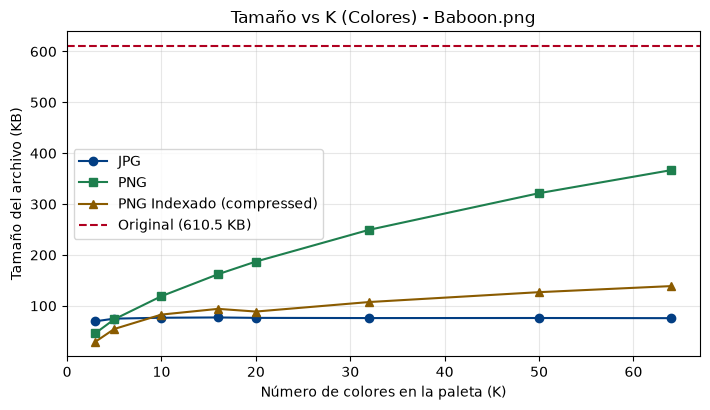

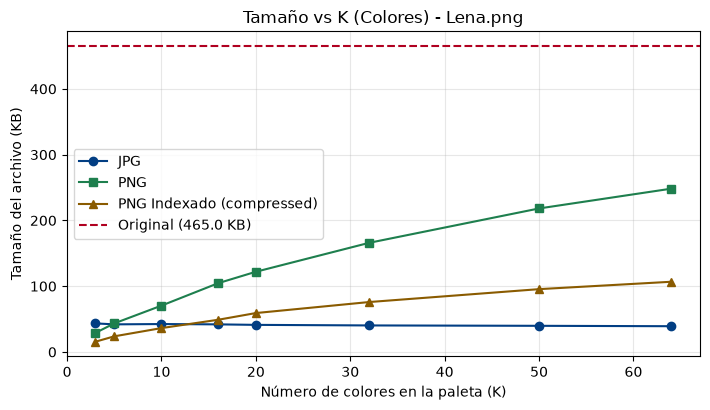

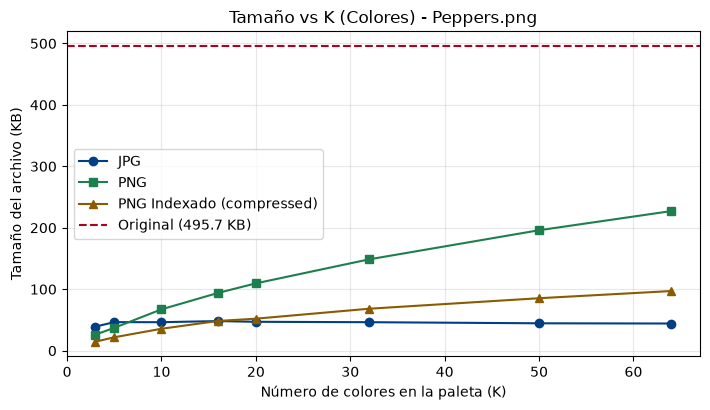

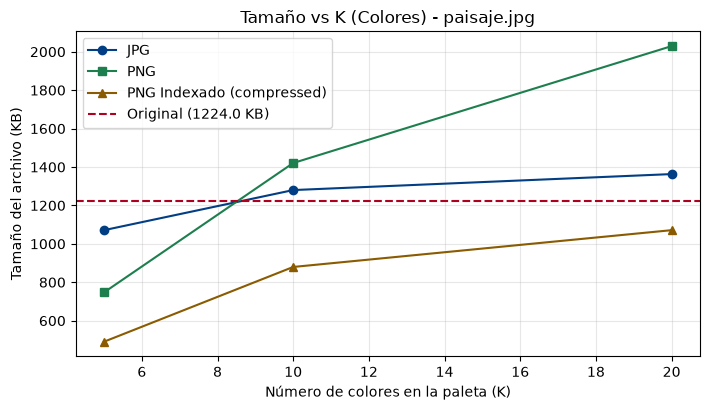

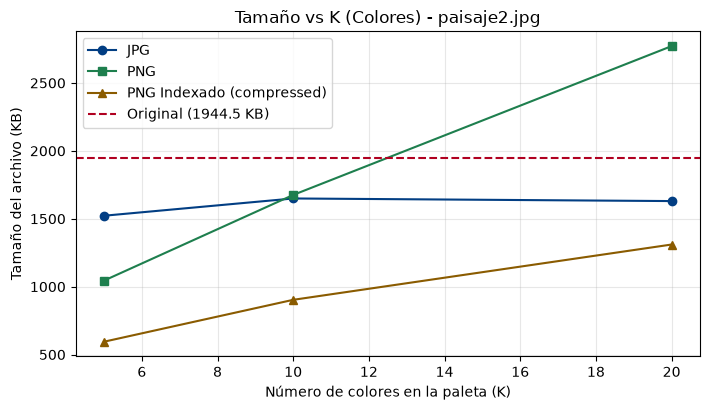

In [ ]:
# TODO (c) For each image, plot size in KB against K with one curve per format
#          (jpg, png, indexed png), and mark the size of the original file.

import os
import matplotlib.pyplot as plt

# Usamos la misma configuración del apartado anterior
config_imagenes = {
    "Baboon.png": [3, 5, 10, 16, 20, 32, 50, 64],
    "Lena.png": [3, 5, 10, 16, 20, 32, 50, 64],
    "Peppers.png": [3, 5, 10, 16, 20, 32, 50, 64],
    "paisaje.jpg": [5, 10, 20],
    "paisaje2.jpg": [5, 10, 20]
}

for img_name, valores_k in config_imagenes.items():
    nombre_base = img_name.split('.')[0]
    
    # 1. Obtener el tamaño de la imagen original
    ruta_original = f"../Files_clustering/images/{img_name}"
    tamano_original = get_size(ruta_original) # Usando tu helper del 4(a)
    
    # Listas para almacenar los tamaños de cada formato
    tamanos_jpg = []
    tamanos_png = []
    tamanos_compressed = []
    
    # 2. Recorrer los K y obtener los tamaños de los 3 archivos generados
    for k in valores_k:
        ruta_base_reducida = f"../reduced_images/{nombre_base}_{k}"
        
        # Leemos los tamaños de los archivos con las extensiones que añade save_image
        tamanos_jpg.append(get_size(ruta_base_reducida + ".jpg"))
        tamanos_png.append(get_size(ruta_base_reducida + ".png"))
        tamanos_compressed.append(get_size(ruta_base_reducida + "compressed.png"))
        
    # 3. Dibujar la gráfica para esta imagen
    fig, ax = plt.subplots(figsize=(7.2, 4.2))
    
    # Curvas para cada formato
    ax.plot(valores_k, tamanos_jpg, marker='o', color='#023E83', label='JPG')
    ax.plot(valores_k, tamanos_png, marker='s', color='#1E7F4E', label='PNG')
    ax.plot(valores_k, tamanos_compressed, marker='^', color='#8A5B00', label='PNG Indexado (compressed)')
    
    # Línea horizontal para el tamaño original
    ax.axhline(y=tamano_original, color='#B00020', linestyle='--', 
               linewidth=1.5, label=f'Original ({tamano_original:.1f} KB)')
    
    ax.set_title(f"Tamaño vs K (Colores) - {img_name}")
    ax.set_xlabel("Número de colores en la paleta (K)")
    ax.set_ylabel("Tamaño del archivo (KB)") 
    ax.grid(alpha=0.3) #Pone la cuadricula de fondo con transparencia 0.3 para que se vean mejor los datos que nos importan
    ax.legend() #Invoca la caja de la leyenda
    
    plt.tight_layout() #Ajusta los márgenes y los espacios internos de la figura
    plt.show()

### 4(d) — interpretation

**TODO.** Answer all four questions of the statement:

1. Which format shrinks as $K$ falls and which barely responds at all — explained from how each format encodes an image.

El formato que reduce drásticamente su tamaño a medida que $K$ disminuye es el PNG (representado por la línea verde del PNG estándar y la marrón del PNG indexado). Este comportamiento es evidente en todas las gráficas; por ejemplo, en paisaje.jpg, el PNG estándar cae desde más de 2000 KB en $K=20$ hasta aproximadamente 750 KB en $K=5$. Por el contrario, el formato JPG (línea azul) es el que apenas responde a los cambios de paleta. En las gráficas de Baboon.png, Lena.png y Peppers.png, la línea del JPG se mantiene prácticamente horizontal en todo el eje. Esto se debe a que el PNG comprime agrupando colores exactos repetidos (favoreciéndose de paletas reducidas), mientras que el JPG no usa paletas, sino que procesa las frecuencias visuales generales de la imagen.

2. Why the JPG at small $K$ can be **larger** than at a much larger $K$.

Las gráficas muestran empíricamente que el tamaño del archivo JPG en un $K$ bajo puede superar al tamaño en un $K$ alto. En la gráfica de Baboon.png, la línea azul del JPG tiene un ligero pico de tamaño cerca de $K=16$ (rozando los 80 KB) que luego desciende y se estabiliza por debajo de ese nivel al llegar a $K=64$. En Lena.png, el JPG en $K=5$ o $K=10$ pesa ligeramente más que en $K=64$. Como el JPG está optimizado para degradados suaves, reducir la imagen a 5 o 16 colores crea bordes duros y saltos artificiales entre píxeles que el algoritmo interpreta como información muy compleja de comprimir, generando archivos más pesados. 

3. What property of the content makes `Baboon.png` behave differently from `Lena.png`.

La propiedad diferenciadora (la textura y alta frecuencia de detalles) se refleja claramente al comparar la evolución del tamaño de los archivos PNG de ambas imágenes. Aunque los archivos originales tienen tamaños comparables (610.5 KB para Baboon y 465.0 KB para Lena), sus versiones PNG escalan a ritmos muy distintos. En $K=64$, el PNG del mandril alcanza unos 370 KB, mientras que el de Lena solo llega a unos 250 KB. La textura caótica del pelo del mandril impide que el PNG encuentre secuencias repetitivas largas para comprimir, a diferencia de los degradados suaves presentes en la foto de Lena.  

4. Looking at the images: at roughly which $K$ does each stop looking obviously damaged, and does that agree with where the size curve flattens?

El momento en el que el tamaño deja de crecer agresivamente coincide con el punto en el que las imágenes deberían dejar de verse muy deterioradas. En las gráficas de Baboon.png, Lena.png y Peppers.png, la curva del PNG Indexado (marrón) muestra un cambio de pendiente (un "codo") y se aplana significativamente a partir de valores entre $K=16$ y $K=32$. En las gráficas de paisaje.jpg y paisaje2.jpg, el tramo de la curva indexada marrón entre $K=10$ y $K=20$ ya muestra una pendiente menos inclinada que el salto abrupto inicial entre $K=5$ y $K=10$. Este aplanamiento indica que, a partir de esos valores de $K$, añadir nuevos colores a la paleta apenas aumenta la complejidad del archivo porque la estructura visual principal ya está bien definida y estabilizada. 

